In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [38]:
df = pd.read_csv("/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv")

In [39]:
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [40]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.drop(columns = ['Serial No.'],inplace = True)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [45]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [47]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_test_scaled

array([[ 0.88      ,  0.85714286,  0.75      ,  0.75      ,  0.57142857,
         0.87820513,  1.        ],
       [ 0.48      ,  0.57142857,  0.75      ,  0.875     ,  0.71428571,
         0.71794872,  1.        ],
       [ 0.5       ,  0.46428571,  0.25      ,  0.25      ,  0.28571429,
         0.2724359 ,  0.        ],
       [ 0.44      ,  0.60714286,  0.5       ,  0.5       ,  0.42857143,
         0.60576923,  0.        ],
       [ 0.72      ,  0.71428571,  0.5       ,  0.625     ,  0.42857143,
         0.72115385,  1.        ],
       [ 0.78      ,  0.67857143,  0.75      ,  0.875     ,  0.71428571,
         0.77884615,  1.        ],
       [ 0.        ,  0.28571429,  0.        ,  0.125     ,  0.14285714,
         0.24358974,  0.        ],
       [ 0.22      ,  0.5       ,  0.75      ,  0.375     ,  0.42857143,
         0.53525641,  0.        ],
       [ 0.56      ,  0.60714286,  0.5       ,  0.625     ,  0.71428571,
         0.77564103,  1.        ],
       [ 0.6       ,  0.7142

In [49]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [50]:
#min_max scaler we will use that when we have an tight idea about the upper bound and lower_bound

In [51]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [52]:
model = Sequential()

In [53]:
#NN ARCH
model.add(Dense(7, activation = 'relu',input_dim = 7))
model.add(Dense(7,activation = 'relu'))
model.add(Dense(1,activation = 'linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(loss = 'mse', optimizer = 'Adam',metrics = ['r2_score'])

In [56]:
history = model.fit(X_train_scaled,y_train,epochs = 400,validation_split = 0.2)

Epoch 1/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.4210 - r2_score: -21.0037 - val_loss: 0.3807 - val_r2_score: -16.4158
Epoch 2/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3521 - r2_score: -17.3988 - val_loss: 0.3113 - val_r2_score: -13.2406
Epoch 3/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2849 - r2_score: -13.8875 - val_loss: 0.2458 - val_r2_score: -10.2439
Epoch 4/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2221 - r2_score: -10.6096 - val_loss: 0.1856 - val_r2_score: -7.4924
Epoch 5/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1655 - r2_score: -7.6495 - val_loss: 0.1323 - val_r2_score: -5.0519
Epoch 6/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1167 - r2_score: -5.0987 - val_loss: 0.0882 - val_r2_score: -3.0375
Epoch 7/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0780 - r2_score: -3.0776 - val_loss: 0.0552 - val_r2_score: -1.5268
Epoch 8/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0495 - r2_score: -1.5

In [57]:
y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [58]:
from sklearn.metrics import r2_score

In [59]:
r2_score(y_test,y_pred)

0.8078447265839419

In [60]:
# history.history

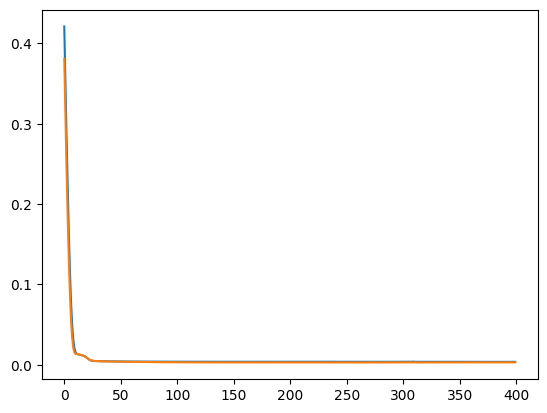

In [61]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

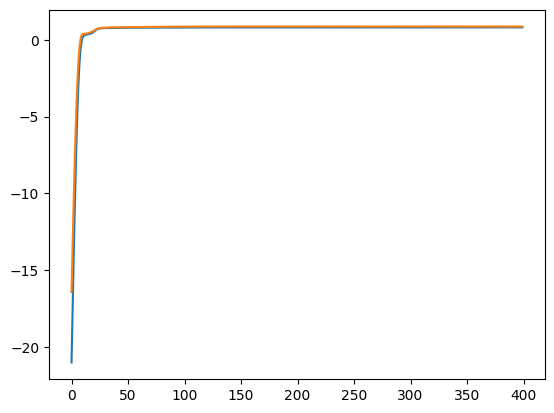

In [62]:
plt.plot(history.history['r2_score'])
plt.plot(history.history['val_r2_score'])